# Исследовательский разбор калибровки `quality_gate`

Цель:
- Проверить, оправдан ли текущий `quality_gate` и доля `unknown / reject` на живой таблице.
- Разложить `quality_reason`, `review_bucket` и сигналы `quality_gate` по понятным сводкам.
- Сравнить базовый, смягченный и строгий варианты политики без изменения рабочего контура.


In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные параметры.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    # Ищем корень репозитория по каталогу .git.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория из текущей рабочей директории.')


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)


In [2]:
# Импортируем calibration-review helpers после добавления src в sys.path.
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    BOOLEAN_LABELS,
    OOD_STATE_LABELS,
    QUALITY_POLICY_LABELS,
    QUALITY_POLICY_METRIC_LABELS,
    QUALITY_STATE_LABELS,
)
from exohost.reporting.quality_gate_calibration_review import (
    DEFAULT_QUALITY_GATE_CALIBRATION_SPECS,
    build_quality_gate_variant_changed_rows_frame,
    build_quality_gate_variant_reason_frame,
    build_quality_gate_variant_summary_frame,
    build_quality_gate_variant_transition_frame,
)
from exohost.reporting.quality_gate_review import (
    build_ood_state_distribution_frame,
    build_quality_gate_signal_summary_frame,
    build_quality_gate_summary_frame,
    build_quality_reason_distribution_frame,
    build_quality_review_crosstab_frame,
    build_quality_state_distribution_frame,
    build_review_bucket_distribution_frame,
    load_quality_gate_review_frame,
    load_unknown_review_frame,
)


## Что делаем

- Загружаем живые таблицы `quality_gated` и `unknown_review`.
- Сначала смотрим общую картину: `quality_state`, `ood_state`, `quality_reason`, `review_bucket`.
- Потом разбираем отдельные сигналы фильтра качества.
- Затем сравниваем базовый, смягченный и строгий варианты политики.
- В конце смотрим реальные строки, у которых вариант политики меняет исходное состояние.


In [3]:
# Конфигурация notebook и словари отображения.
QUALITY_GATE_LIMIT: int | None = None
UNKNOWN_REVIEW_LIMIT: int | None = None
TOP_REASON_ROWS = 20
TOP_CHANGED_ROWS = 25

VARIANT_SPECS = DEFAULT_QUALITY_GATE_CALIBRATION_SPECS
BASELINE_SPEC = next(spec for spec in VARIANT_SPECS if spec.policy_name == "baseline")
RELAXED_SPEC = next(spec for spec in VARIANT_SPECS if spec.policy_name == "relaxed")
STRICT_SPEC = next(spec for spec in VARIANT_SPECS if spec.policy_name == "strict")


In [4]:
# Загружаем живые audit-таблицы и собираем основные сводки.
quality_gate_df = load_quality_gate_review_frame(limit=QUALITY_GATE_LIMIT)
unknown_review_df = load_unknown_review_frame(limit=UNKNOWN_REVIEW_LIMIT)

quality_gate_summary_df = build_quality_gate_summary_frame(quality_gate_df)
unknown_review_summary_df = build_quality_gate_summary_frame(unknown_review_df)
quality_state_df = build_quality_state_distribution_frame(quality_gate_df)
ood_state_df = build_ood_state_distribution_frame(quality_gate_df)
quality_reason_df = build_quality_reason_distribution_frame(quality_gate_df, top_n=TOP_REASON_ROWS)
review_bucket_df = build_review_bucket_distribution_frame(quality_gate_df, top_n=TOP_REASON_ROWS)
quality_signal_df = build_quality_gate_signal_summary_frame(quality_gate_df)
quality_review_crosstab_df = build_quality_review_crosstab_frame(quality_gate_df)

summary_column_mapping = {
    'n_rows': 'Число строк',
    'n_unique_source_id': 'Число уникальных source_id',
    'n_pass_rows': 'Строк `pass`',
    'n_unknown_rows': 'Строк `unknown`',
    'n_reject_rows': 'Строк `reject`',
    'n_in_domain_rows': 'Строк `in_domain`',
    'n_candidate_ood_rows': 'Строк `candidate_ood`',
    'n_ood_rows': 'Строк `ood`',
}
state_column_mapping = {
    'quality_state': 'Состояние фильтра качества',
    'ood_state': 'Состояние контура OOD',
    'n_rows': 'Число строк',
    'share': 'Доля',
}

display(rename_frame_for_display(quality_gate_summary_df, column_mapping=summary_column_mapping))
display(rename_frame_for_display(unknown_review_summary_df, column_mapping=summary_column_mapping))
display(
    rename_frame_for_display(
        quality_state_df,
        column_mapping=state_column_mapping,
        value_mapping={'quality_state': QUALITY_STATE_LABELS},
    )
)
display(
    rename_frame_for_display(
        ood_state_df,
        column_mapping=state_column_mapping,
        value_mapping={'ood_state': OOD_STATE_LABELS},
    )
)


,Число строк,Число уникальных source_id,Строк `pass`,Строк `unknown`,Строк `reject`,Строк `in_domain`,Строк `candidate_ood`,Строк `ood`
0,402226,402226,178439,63823,159964,366153,35885,188


,Число строк,Число уникальных source_id,Строк `pass`,Строк `unknown`,Строк `reject`,Строк `in_domain`,Строк `candidate_ood`,Строк `ood`
0,235379,235379,11592,63823,159964,199306,35885,188


,Состояние фильтра качества,Число строк,Доля
0,Допуск,178439,0.443629
1,Отклонено,159964,0.397697
2,Проверить,63823,0.158674


,Состояние контура OOD,Число строк,Доля
0,Внутри домена,366153,0.910317
1,Пограничный OOD,35885,0.089216
2,OOD,188,0.000467


In [5]:
# Причины срабатывания, группы проверки и покрытие сигналов `quality_gate`.
display(
    rename_frame_for_display(
        quality_reason_df,
        column_mapping={'quality_reason': 'Причина `quality_gate`', 'n_rows': 'Число строк', 'share': 'Доля'},
    )
)
display(
    rename_frame_for_display(
        review_bucket_df,
        column_mapping={'review_bucket': 'Группа проверки', 'n_rows': 'Число строк', 'share': 'Доля'},
    )
)
display(
    rename_frame_for_display(
        quality_signal_df,
        column_mapping={
            'signal_name': 'Сигнал',
            'n_rows_true': 'Строк с сигналом',
            'share_true': 'Доля строк с сигналом',
            'n_pass_true': 'Строк `pass` с сигналом',
            'n_unknown_true': 'Строк `unknown` с сигналом',
            'n_reject_true': 'Строк `reject` с сигналом',
            'n_in_domain_true': 'Строк `in_domain` с сигналом',
            'n_candidate_ood_true': 'Строк `candidate_ood` с сигналом',
            'n_ood_true': 'Строк `ood` с сигналом',
        },
    )
)
display(quality_review_crosstab_df.rename_axis(index='Состояние фильтра качества', columns='Причина проверки'))


,Причина `quality_gate`,Число строк,Доля
0,pass,178439,0.443629
1,missing_core_features,159964,0.397697
2,high_ruwe,39966,0.099362
3,missing_radius_flame,18406,0.045760
4,low_parallax_snr,5451,0.013552


,Группа проверки,Число строк,Доля
0,pass,166847,0.414809
1,reject_missing_core_features,159873,0.397471
2,review_high_ruwe,28388,0.070577
3,review_missing_radius_flame,16762,0.041673
4,review_non_single_star,14402,0.035806
5,review_low_single_star_probability,10474,0.026040
6,review_low_parallax_snr,5292,0.013157
7,ood,188,0.000467


,Сигнал,Строк с сигналом,Доля строк с сигналом,Строк `pass` с сигналом,Строк `unknown` с сигналом,Строк `reject` с сигналом,Строк `in_domain` с сигналом,Строк `candidate_ood` с сигналом,Строк `ood` с сигналом
0,has_core_features,242262,0.602303,178439,63823,0,217289,24876,97
1,has_flame_features,223858,0.556548,178439,45417,2,200529,23301,28
2,has_non_single_star_flag,22860,0.056834,3958,10444,8458,0,22859,1
3,has_low_single_star_probability,14171,0.035231,7859,3562,2750,0,14131,40
4,has_missing_core_features,159964,0.397697,0,0,159964,148864,11009,91
5,has_missing_flame_features,178368,0.443452,0,18406,159962,165624,12584,160
6,has_high_ruwe,67376,0.167508,0,41582,25794,48901,18460,15
7,has_low_parallax_snr,37837,0.094069,0,17967,19870,35942,1828,67


Причина проверки,ood,pass,reject_missing_core_features,review_high_ruwe,review_low_parallax_snr,review_low_single_star_probability,review_missing_radius_flame,review_non_single_star
Состояние фильтра качества,,,,,,,,
pass,20,166847,0,0,0,7614,0,3958
reject,91,0,159873,0,0,0,0,0
unknown,77,0,0,28388,5292,2860,16762,10444


In [6]:
# Сравниваем базовый, смягченный и строгий варианты политики.
variant_summary_df = build_quality_gate_variant_summary_frame(quality_gate_df, specs=VARIANT_SPECS)
baseline_transition_df = build_quality_gate_variant_transition_frame(quality_gate_df, spec=BASELINE_SPEC)
relaxed_transition_df = build_quality_gate_variant_transition_frame(quality_gate_df, spec=RELAXED_SPEC)
strict_transition_df = build_quality_gate_variant_transition_frame(quality_gate_df, spec=STRICT_SPEC)
relaxed_reason_df = build_quality_gate_variant_reason_frame(quality_gate_df, spec=RELAXED_SPEC, top_n=TOP_REASON_ROWS)
strict_reason_df = build_quality_gate_variant_reason_frame(quality_gate_df, spec=STRICT_SPEC, top_n=TOP_REASON_ROWS)

variant_value_mapping = {
    'policy_name': QUALITY_POLICY_LABELS,
    'require_flame_for_pass': BOOLEAN_LABELS,
}

display(
    rename_frame_for_display(
        variant_summary_df,
        column_mapping={
            'policy_name': 'Вариант политики',
            'ruwe_unknown_threshold': 'Порог RUWE для `unknown`',
            'parallax_snr_unknown_threshold': 'Порог SNR параллакса для `unknown`',
            'require_flame_for_pass': 'Нужен FLAME для `pass`',
            'n_rows': 'Число строк',
            'n_pass_rows': 'Строк `pass`',
            'n_unknown_rows': 'Строк `unknown`',
            'n_reject_rows': 'Строк `reject`',
            'share_pass': 'Доля `pass`',
            'share_unknown': 'Доля `unknown`',
            'share_reject': 'Доля `reject`',
        },
        value_mapping=variant_value_mapping,
    )
)
display(relaxed_transition_df.rename_axis(index='Исходное состояние', columns='Состояние в смягченном варианте'))
display(strict_transition_df.rename_axis(index='Исходное состояние', columns='Состояние в строгом варианте'))
display(
    rename_frame_for_display(
        relaxed_reason_df,
        column_mapping={'variant_quality_reason': 'Причина в смягченном варианте', 'n_rows': 'Число строк', 'share': 'Доля'},
    )
)
display(
    rename_frame_for_display(
        strict_reason_df,
        column_mapping={'variant_quality_reason': 'Причина в строгом варианте', 'n_rows': 'Число строк', 'share': 'Доля'},
    )
)


,Вариант политики,Порог RUWE для `unknown`,Порог SNR параллакса для `unknown`,Нужен FLAME для `pass`,Число строк,Строк `pass`,Строк `unknown`,Строк `reject`,Доля `pass`,Доля `unknown`,Доля `reject`
0,Базовый вариант,1.4,5.0,Да,402226,178439,63823,159964,0.443629,0.158674,0.397697
1,Смягченный вариант,1.6,3.0,Нет,402226,195815,46447,159964,0.486828,0.115475,0.397697
2,Строгий вариант,1.2,7.0,Да,402226,162741,79521,159964,0.404601,0.197702,0.397697


Состояние в смягченном варианте,pass,reject,unknown
Исходное состояние,,,
pass,178439,0,0
reject,0,159964,0
unknown,17376,0,46447


Состояние в строгом варианте,pass,reject,unknown
Исходное состояние,,,
pass,162741,0,15698
reject,0,159964,0
unknown,0,0,63823


,Причина в смягченном варианте,Число строк,Доля
0,pass,195815,0.486828
1,missing_core_features,159964,0.397697
2,review_high_ruwe,35087,0.087232
3,review_low_parallax_snr,11360,0.028243


,Причина в строгом варианте,Число строк,Доля
0,pass,162741,0.404601
1,missing_core_features,159964,0.397697
2,review_high_ruwe,56678,0.140911
3,review_low_parallax_snr,17560,0.043657
4,review_missing_radius_flame,5283,0.013134


In [7]:
# Показываем реальные объекты, для которых смягченный или строгий вариант меняет исходное состояние.
relaxed_changed_df = build_quality_gate_variant_changed_rows_frame(
    quality_gate_df,
    spec=RELAXED_SPEC,
    top_n=TOP_CHANGED_ROWS,
)
strict_changed_df = build_quality_gate_variant_changed_rows_frame(
    quality_gate_df,
    spec=STRICT_SPEC,
    top_n=TOP_CHANGED_ROWS,
)

changed_column_mapping = {
    'source_id': 'source_id',
    'quality_state': 'Исходное состояние `quality_gate`',
    'variant_quality_state': 'Состояние в варианте политики',
    'quality_reason': 'Исходная причина `quality_gate`',
    'variant_quality_reason': 'Причина в варианте политики',
    'review_bucket': 'Группа проверки',
    'ruwe': 'RUWE',
    'parallax_over_error': 'SNR параллакса',
    'radius_flame': 'Радиус FLAME',
    'non_single_star': 'Признак non_single_star',
    'classprob_dsc_combmod_star': 'Вероятность single-star по DSC',
    'spectral_class': 'Спектральный класс',
    'spectral_subclass': 'Спектральный подкласс',
}

display(rename_frame_for_display(relaxed_changed_df, column_mapping=changed_column_mapping))
display(rename_frame_for_display(strict_changed_df, column_mapping=changed_column_mapping))


,source_id,Исходное состояние `quality_gate`,Состояние в варианте политики,Исходная причина `quality_gate`,Причина в варианте политики,Группа проверки,RUWE,SNR параллакса,Радиус FLAME,Признак non_single_star,Вероятность single-star по DSC,Спектральный класс,Спектральный подкласс
3,5337126683614332288,unknown,pass,missing_radius_flame,pass,review_missing_radius_flame,0.797329,13.130674,NaN,0,1.000000,OB,NaN
23,435920664946727936,unknown,pass,high_ruwe,pass,review_high_ruwe,1.549145,80.451320,11.339561,0,0.999990,G,7.0
49,2510973086812132224,unknown,pass,missing_radius_flame,pass,review_missing_radius_flame,1.112701,4.426817,NaN,0,0.999983,M,1.0
71,4449969332819243264,unknown,pass,missing_radius_flame,pass,review_missing_radius_flame,0.897810,13.014542,NaN,0,0.999665,M,3.0
81,4500728841169873408,unknown,pass,high_ruwe,pass,review_high_ruwe,1.559400,13.334695,7.003821,0,0.999911,K,NaN
99,4057967603350971136,unknown,pass,missing_radius_flame,pass,ood,0.924329,6.364651,NaN,0,1.000000,M,NaN
124,4063440727359056768,unknown,pass,high_ruwe,pass,review_high_ruwe,1.543128,67.636444,2.457951,0,0.999886,F,8.0
142,2544049454593014528,unknown,pass,missing_radius_flame,pass,review_missing_radius_flame,1.012254,3.617640,NaN,0,0.999994,M,0.0
154,3238688641524402048,unknown,pass,high_ruwe,pass,review_high_ruwe,1.438476,93.085430,1.490020,0,0.999324,G,5.0
225,2080159043507023488,unknown,pass,low_parallax_snr,pass,review_low_parallax_snr,1.005924,4.413217,0.628440,0,0.999986,G,8.0


,source_id,Исходное состояние `quality_gate`,Состояние в варианте политики,Исходная причина `quality_gate`,Причина в варианте политики,Группа проверки,RUWE,SNR параллакса,Радиус FLAME,Признак non_single_star,Вероятность single-star по DSC,Спектральный класс,Спектральный подкласс
12,2558052250568143360,pass,unknown,pass,review_high_ruwe,pass,1.270614,255.043400,0.894112,0,0.999640,G,0.0
35,1163496474299552384,pass,unknown,pass,review_high_ruwe,pass,1.205363,89.375110,2.205456,0,0.999640,G,NaN
134,5870817361311371008,pass,unknown,pass,review_high_ruwe,pass,1.385859,66.215760,3.174719,0,0.999644,A,2.0
143,4054432020595636608,pass,unknown,pass,review_low_parallax_snr,pass,1.038056,6.140118,80.107280,0,1.000000,M,5.0
199,3102285939107758080,pass,unknown,pass,review_high_ruwe,pass,1.260319,34.707645,1.637415,0,0.999968,F,7.0
221,1793021096572761216,pass,unknown,pass,review_high_ruwe,pass,1.226284,25.088560,3.923644,0,0.999935,A,2.0
274,6323467572374371840,pass,unknown,pass,review_high_ruwe,review_low_single_star_probability,1.201548,175.823210,1.737850,0,0.000001,F,8.0
279,5251113847464136576,pass,unknown,pass,review_high_ruwe,pass,1.383907,130.917470,11.235598,0,0.999977,G,8.0
306,6449020427193741952,pass,unknown,pass,review_high_ruwe,pass,1.243316,78.193570,1.760923,0,0.999942,A,1.0
358,5285286222161291008,pass,unknown,pass,review_high_ruwe,pass,1.271001,160.228470,9.891059,0,0.999937,G,8.0


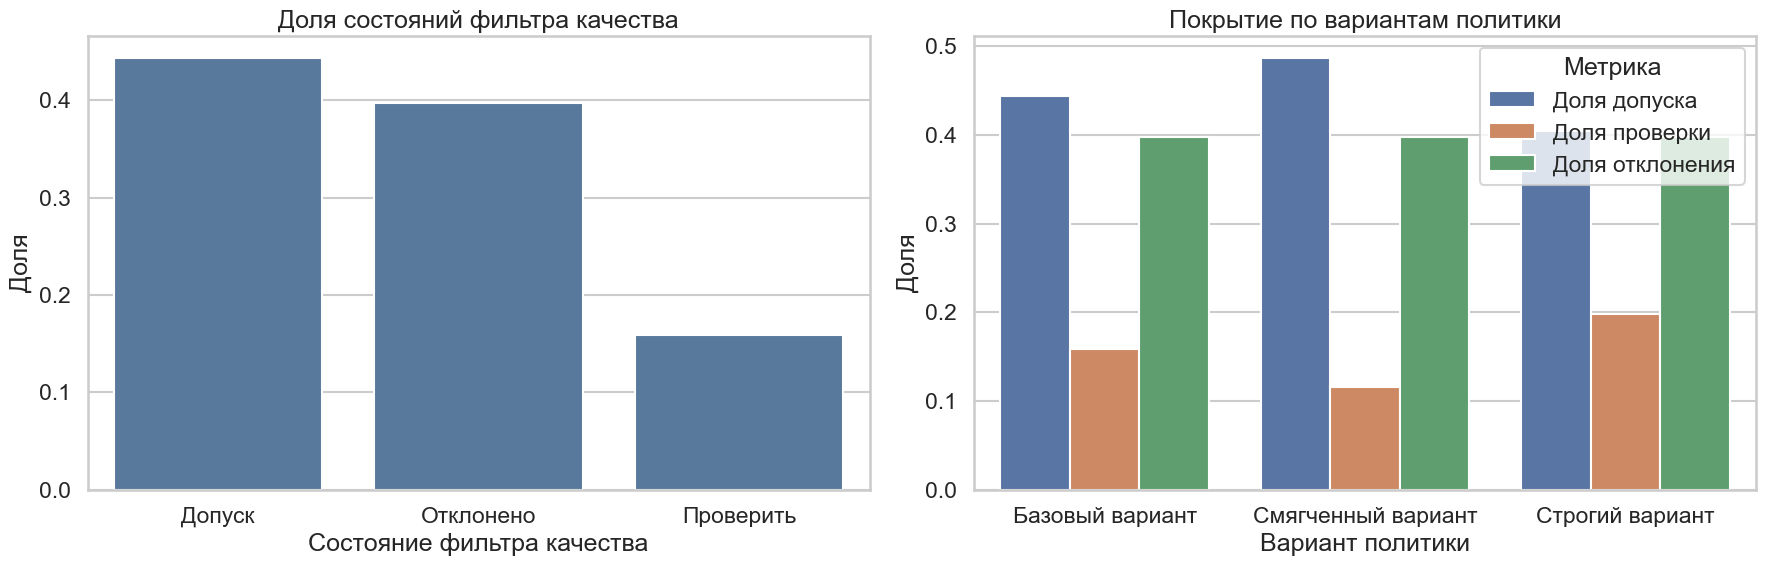

In [8]:
# Короткие графики для быстрой визуальной сверки текущего состояния и вариантов политики.
quality_state_plot_df = quality_state_df.copy()
quality_state_plot_df['quality_state'] = quality_state_plot_df['quality_state'].map(
    lambda value: QUALITY_STATE_LABELS.get(str(value), str(value))
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=quality_state_plot_df, x='quality_state', y='share', ax=axes[0], color='#4C78A8')
axes[0].set_title('Доля состояний фильтра качества')
axes[0].set_ylabel('Доля')
axes[0].set_xlabel('Состояние фильтра качества')

variant_plot_df = variant_summary_df.melt(
    id_vars='policy_name',
    value_vars=['share_pass', 'share_unknown', 'share_reject'],
    var_name='metric_name',
    value_name='metric_value',
)
variant_plot_df['policy_name'] = variant_plot_df['policy_name'].map(
    lambda value: QUALITY_POLICY_LABELS.get(str(value), str(value))
)
variant_plot_df['metric_name'] = variant_plot_df['metric_name'].map(
    lambda value: QUALITY_POLICY_METRIC_LABELS.get(str(value), str(value))
)
sns.barplot(data=variant_plot_df, x='policy_name', y='metric_value', hue='metric_name', ax=axes[1])
axes[1].set_title('Покрытие по вариантам политики')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('Вариант политики')
axes[1].legend(title='Метрика')
plt.tight_layout()
plt.show()


## Краткий вывод

- Этот ноутбук не меняет рабочий `quality_gate`, а только сравнивает варианты политики поверх живой audit-таблицы.
- `RUWE <= 1.4` здесь трактуется как консервативная проектная политика, а не как универсальный жесткий порог Gaia.
- Следующий шаг после обзора: принять решение, оставляем ли текущую долю `unknown`, или переводим часть правил из `reject` в контур проверки.
